# Notebook 5: Plot overpass times and input data for methods section

## Imports

In [1]:
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
out_dir = "./plots/"

##  Get and prepare data

In [3]:
time_slice = slice(
    "2025-05-28",
    "2025-05-31"
)

In [4]:
modis_file = "./data/modis/modis_active_fire_data.csv"

modis = xr.Dataset.from_dataframe(pd.read_csv(modis_file))
modis["acq_date"] = modis["acq_date"].astype("datetime64[ns]")

In [5]:
dates = modis["acq_date"].values
times = modis["acq_time"].values

hours = times // 100
minutes = times % 100

modis_datetimes = (
    dates.astype("datetime64[D]")
    + hours.astype("timedelta64[h]")
    + minutes.astype("timedelta64[m]")
)


In [6]:
modis_ges = xr.open_dataset("./data/modis/modis_regridded.nc", engine="netcdf4")

modis_frp = (
    modis_ges.frp
    .sel(time=time_slice)
    .where(lambda x: x > -10)
    .mean(dim="cell")
)

## Plot data

In [7]:
# -------------------------------------------------
# Plot settings
# -------------------------------------------------
fs = 14

figsize = (14, 6)

# Overpass positions
y_terra = 2.6
y_aqua = 2.4
y_limits = (1.8, 3.2)

# Overpass appearance
terra_color = "darkred"
aqua_color = "darkblue"
terra_size = 150
aqua_size = 120
overpass_linewidth = 1.6

# Time axis
x_start = np.datetime64("2025-05-28T00:00:00")
x_end = np.datetime64("2025-05-31T00:00:00")

# Local-time markers
border = 20
local_time_offset = 6

# Nighttime
sunrise_hour = 9 + 50 / 60
sunset_hour = 3 + 10 / 60
night_color = "k"
night_alpha = 0.2

# PyroCb
pyro_start = np.datetime64("2025-05-30T01:00:00")
pyro_end = np.datetime64("2025-05-30T04:00:00")
pyro_color = "red"
pyro_alpha = 0.3

# FRP
frp_scale = 0.7
frp_color = "orange"
frp_linewidth = 2.5
frp_ylim = (0, 0.8)

# Figure elements
day_line_color = "red"
day_line_alpha = 0.35
local_line_color = "gray"
local_line_alpha = 0.5

# Time-axis formatting
major_tick_hours = [0, 12]
date_format = "%Y-%m-%d %H:%M"

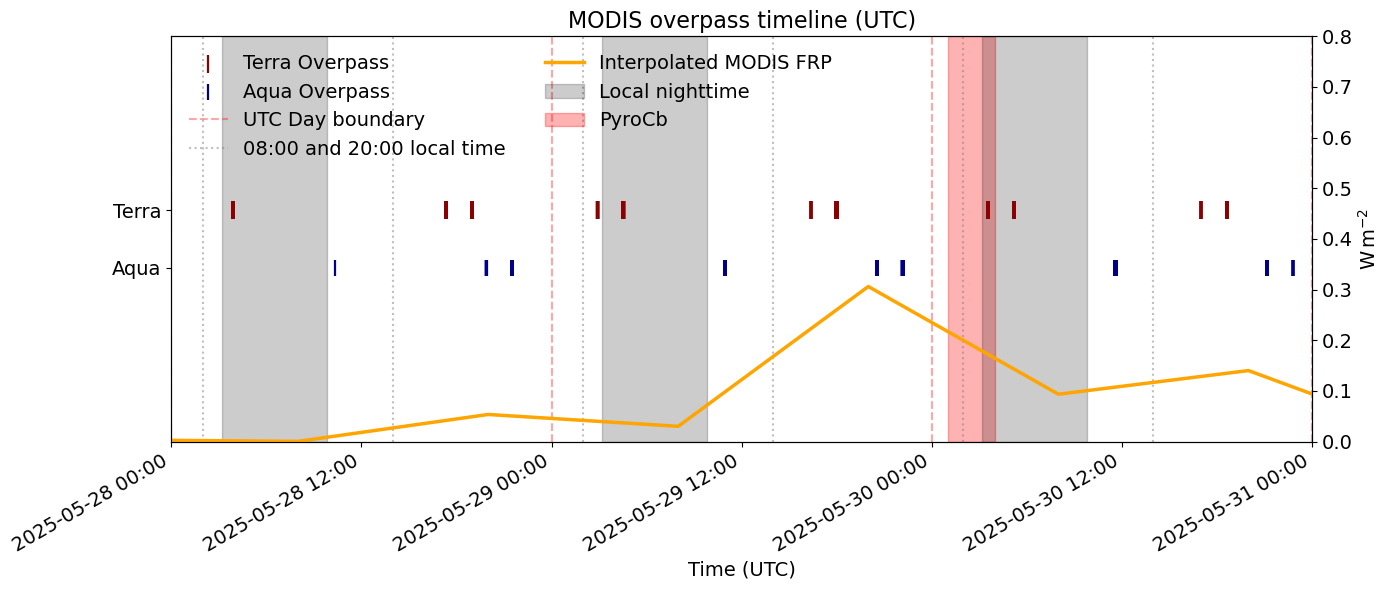

In [8]:

# -------------------------------------------------
# MODIS overpasses
# -------------------------------------------------
terra_mask = modis["satellite"].values == "Terra"
aqua_mask = modis["satellite"].values == "Aqua"

terra_times = modis_datetimes[terra_mask]
aqua_times = modis_datetimes[aqua_mask]

fig, ax = plt.subplots(figsize=figsize)

ax.scatter(
    terra_times,
    np.full(len(terra_times), y_terra),
    marker="|",
    s=terra_size,
    linewidths=overpass_linewidth,
    color=terra_color,
    label="Terra Overpass",
)

ax.scatter(
    aqua_times,
    np.full(len(aqua_times), y_aqua),
    marker="|",
    s=aqua_size,
    linewidths=overpass_linewidth,
    color=aqua_color,
    label="Aqua Overpass",
)

ax.set_yticks([y_terra, y_aqua])
ax.set_yticklabels(["Terra", "Aqua"])
ax.set_ylim(y_limits)

ax.set_title("MODIS overpass timeline (UTC)", fontsize=fs + 2)
ax.set_xlabel("Time (UTC)", fontsize=fs)
ax.tick_params(axis="both", labelsize=fs)

# -------------------------------------------------
# Time axis
# -------------------------------------------------
ax.xaxis.set_major_locator(
    mdates.HourLocator(byhour=major_tick_hours)
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter(date_format)
)

# -------------------------------------------------
# Day boundaries and local-time markers
# -------------------------------------------------
all_datetimes = np.concatenate([terra_times, aqua_times])
unique_days = np.unique(all_datetimes.astype("datetime64[D]"))

day_line_added = False
local_line_added = False

for day in unique_days:

    am_local = day + np.timedelta64(
        border + local_time_offset, "h"
    )
    pm_local = day + np.timedelta64(
        border + local_time_offset + 12 - 24, "h"
    )

    ax.axvline(
        day,
        color=day_line_color,
        linestyle="--",
        alpha=day_line_alpha,
        zorder=0,
        label="UTC Day boundary" if not day_line_added else None,
    )
    day_line_added = True

    ax.axvline(
        am_local,
        color=local_line_color,
        linestyle=":",
        alpha=local_line_alpha,
        zorder=0,
        label=(
            "08:00 and 20:00 local time"
            if not local_line_added
            else None
        ),
    )

    ax.axvline(
        pm_local,
        color=local_line_color,
        linestyle=":",
        alpha=local_line_alpha,
        zorder=0,
    )
    local_line_added = True

# -------------------------------------------------
# Nighttime shading
# -------------------------------------------------
for day in unique_days:

    day_start = np.datetime64(day)

    sunrise = day_start + np.timedelta64(
        int(sunrise_hour * 3600), "s"
    )
    sunset = day_start + np.timedelta64(
        int(sunset_hour * 3600), "s"
    )

    ax.axvspan(
        sunset,
        sunrise,
        color=night_color,
        alpha=night_alpha,
        zorder=-1,
    )

# -------------------------------------------------
# PyroCb period
# -------------------------------------------------
ax.axvspan(
    pyro_start,
    pyro_end,
    color=pyro_color,
    alpha=pyro_alpha,
    zorder=-2,
)

# -------------------------------------------------
# MODIS FRP
# -------------------------------------------------
ax2 = ax.twinx()

ax2.plot(
    modis_frp.time,
    modis_frp * frp_scale,
    color=frp_color,
    linewidth=frp_linewidth,
    label="Interpolated MODIS FRP",
)

ax2.set_ylabel(r"W$\,$m$^{-2}$", fontsize=fs)
ax2.set_ylim(frp_ylim)

ax2.tick_params(
    axis="y",
    labelsize=fs,
    labelcolor="black",
)

ax2.spines["right"].set_color("black")

# -------------------------------------------------
# Legend
# -------------------------------------------------
night_patch = mpatches.Patch(
    color=night_color,
    alpha=night_alpha,
    label="Local nighttime",
)

pyro_patch = mpatches.Patch(
    color=pyro_color,
    alpha=pyro_alpha,
    label="PyroCb",
)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    handles1 + handles2 + [night_patch, pyro_patch],
    labels1 + labels2 + ["Local nighttime", "PyroCb"],
    loc="upper left",
    ncol=2,
    fontsize=fs,
    frameon=False,
)

# -------------------------------------------------
# Limits and layout
# -------------------------------------------------
ax.set_xlim(x_start, x_end)

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

plt.tight_layout()
plt.show()
fig.savefig(out_dir + "overpasses.png",
            dpi=300, bbox_inches="tight")